In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Enforce consistent high-res styling for exports
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "figure.dpi": 300})

filepath = "/content/Epic Universe Wait Times 5_22-5_29.xlsx"
xls = pd.ExcelFile(filepath)

# Extract only the daily data sheets, ignoring any summary tabs
daily_sheets = [s for s in xls.sheet_names if s.isdigit()]
all_daily_data = []

for sheet in daily_sheets:
    raw_df = pd.read_excel(filepath, sheet_name=sheet, header=None)

    # The header row shifts between sheets, so we dynamically anchor it to the '9 A.M.' cell
    h_idx = next((idx for idx, row in raw_df.iterrows() if "9 A.M." in row.values), None)

    if h_idx is not None:
        df = pd.read_excel(filepath, sheet_name=sheet, header=h_idx)
        cols = list(df.columns)
        df = df.rename(columns={cols[1]: "Ride Names"})

        # Strip empty records and ignore generalized park weather rows
        df = df.dropna(subset=["Ride Names"])
        df = df[df["Ride Names"].astype(str).str.strip() != "Weather"]

        # Standardize date format dynamically from sheet names
        day_num = sheet[-2:] if len(sheet) == 3 else sheet
        df["Date"] = f"2025-05-{day_num}"
        all_daily_data.append(df)

master_df = pd.concat(all_daily_data, ignore_index=True)

# Flatten the time columns into a standard long-format time series
hour_cols = [
    c for c in master_df.columns
    if "A.M." in str(c) or "P.M." in str(c) or "AM" in str(c) or "PM" in str(c)
]
long_df = master_df.melt(
    id_vars=["Ride Names", "Date"],
    value_vars=hour_cols,
    var_name="Hour",
    value_name="WaitTime",
)

long_df["Hour"] = long_df["Hour"].str.strip()
long_df["Ride Names"] = long_df["Ride Names"].str.strip()
long_df["WaitTime"] = pd.to_numeric(long_df["WaitTime"], errors="coerce").fillna(0)

# Define standard operating hours for chronological sorting downstream
hour_order = [
    "9 A.M.", "10 A.M.", "11 A.M.", "12 P.M.", "1 P.M.", "2 P.M.",
    "3 P.M.", "4 P.M.", "5 P.M.", "6 P.M.", "7 P.M.", "8 P.M.",
    "9 P.M.", "10 P.M."
]

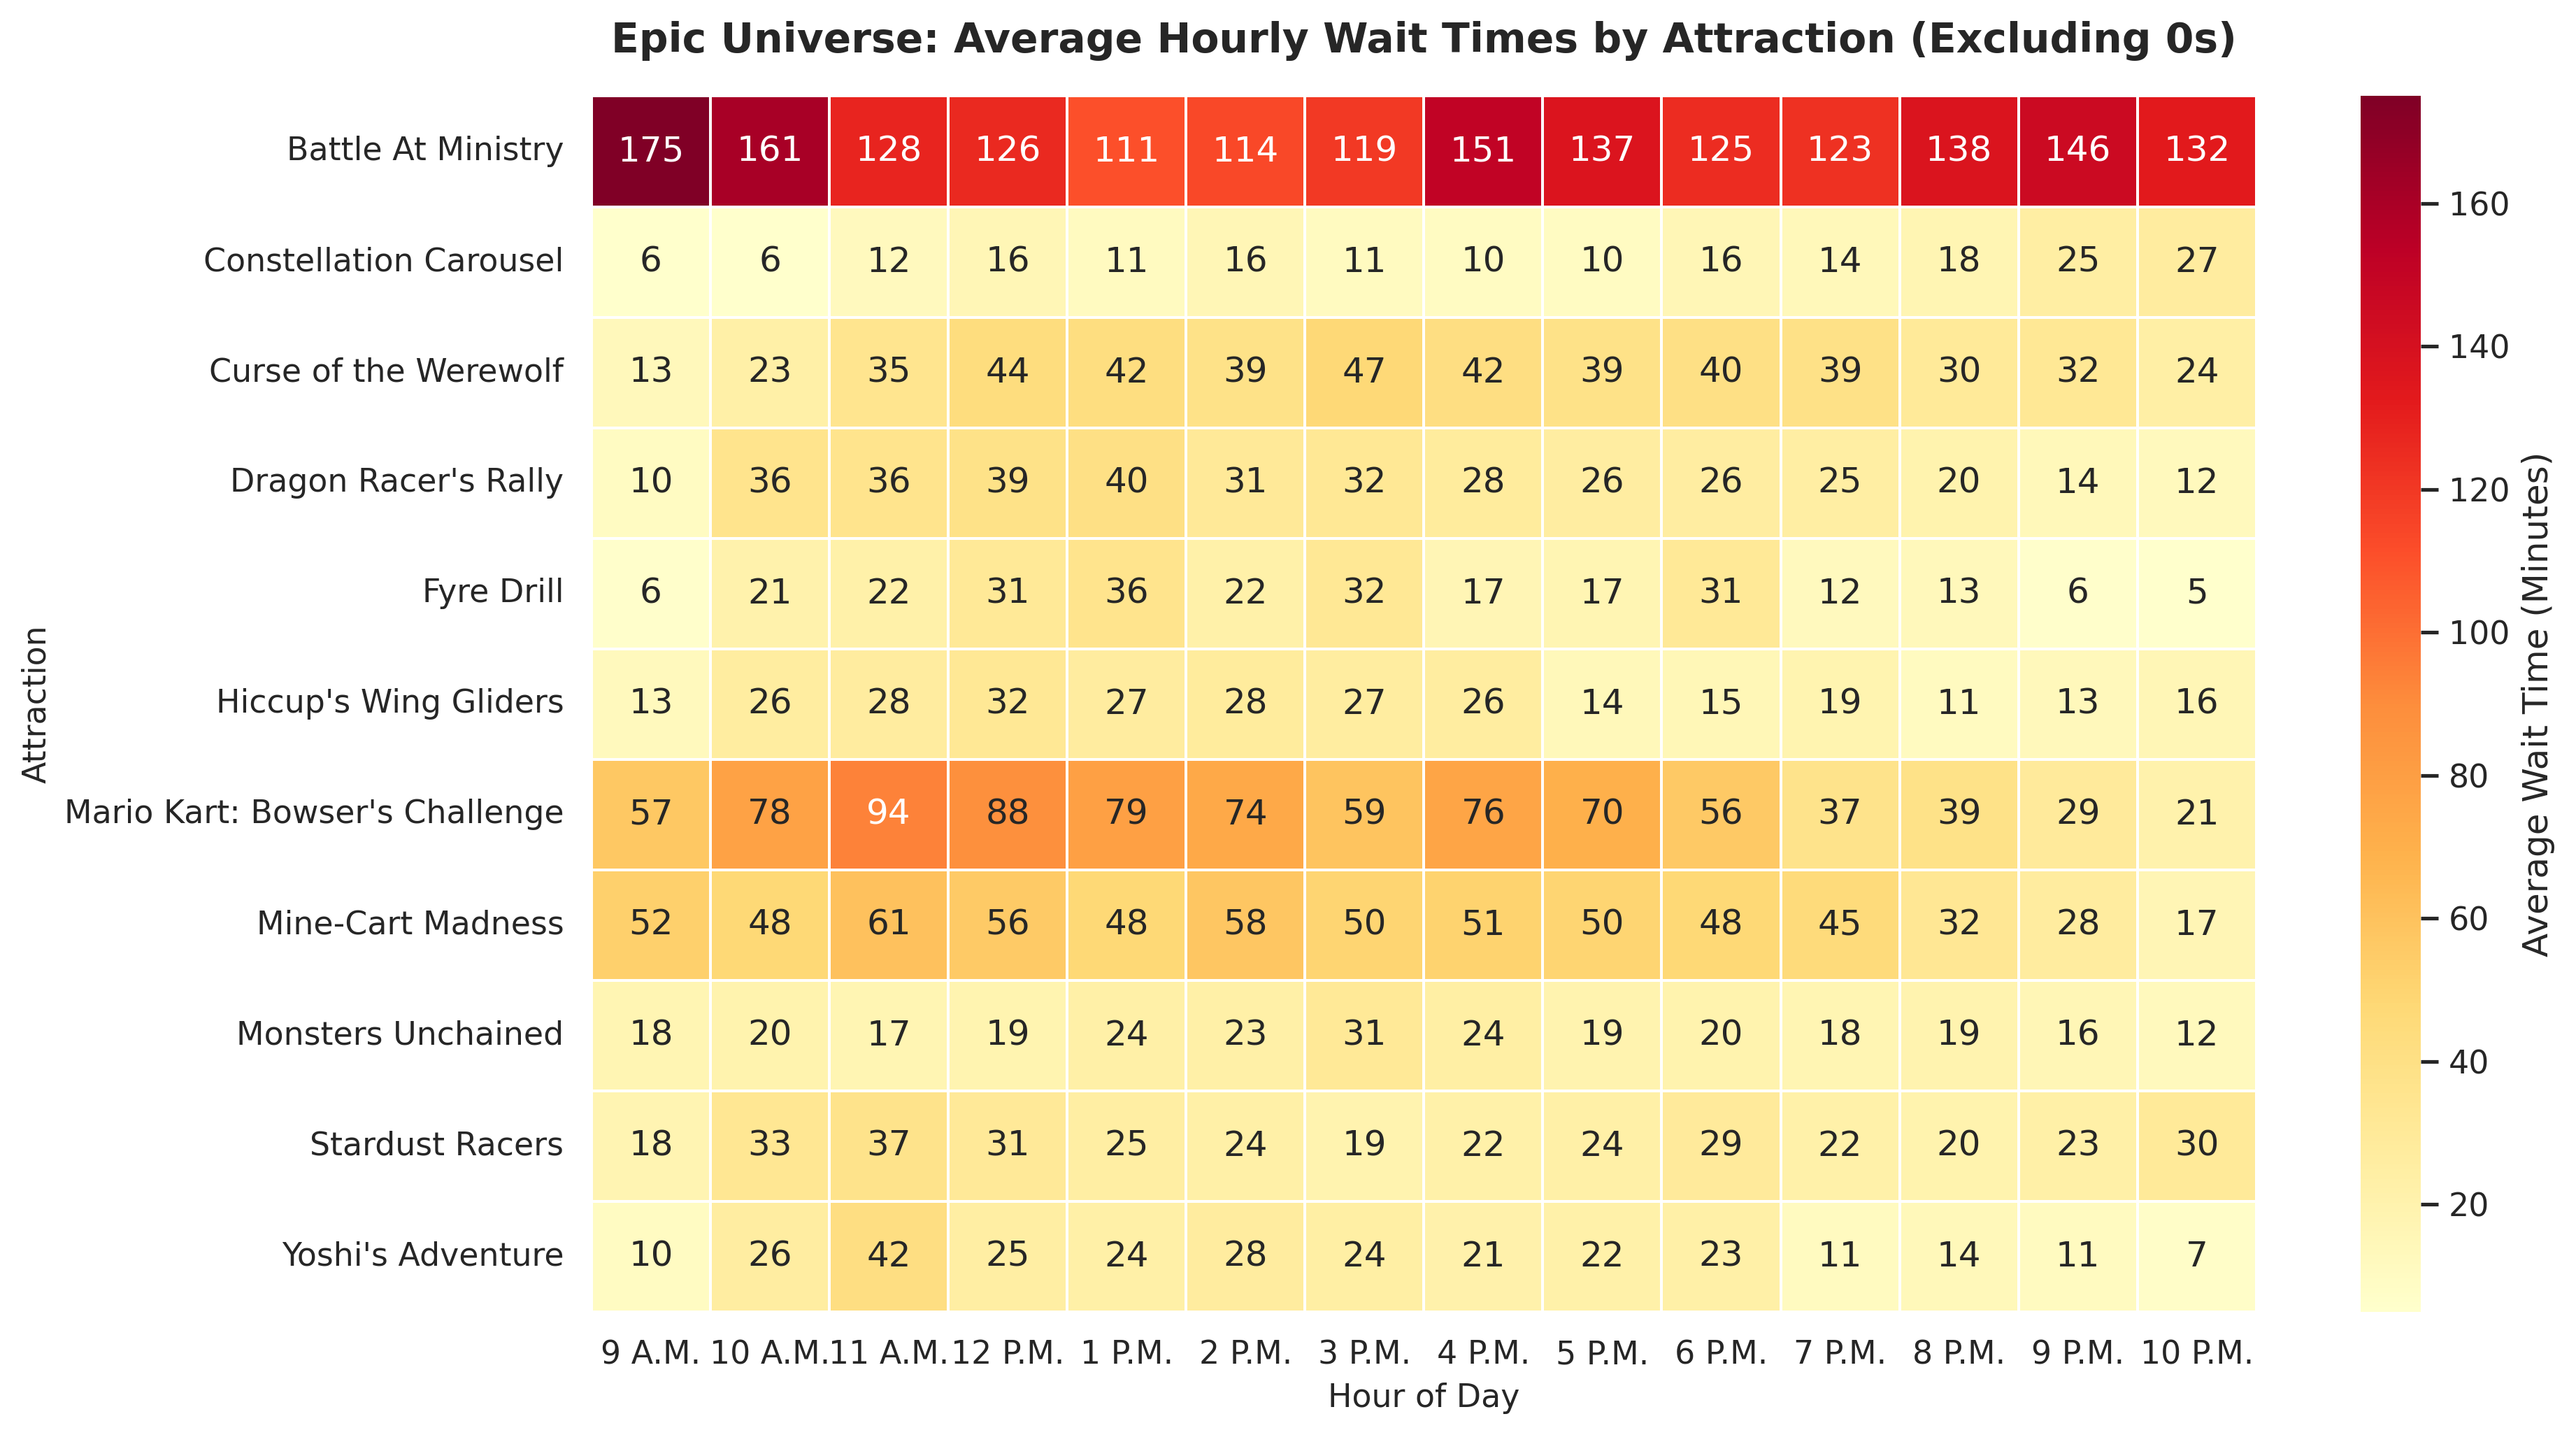

In [52]:
# Prevent 0-minute wait times (closed rides or recording errors) from skewing hourly averages
clean_long_df = long_df.copy()
clean_long_df["WaitTime"] = clean_long_df["WaitTime"].replace(0, float("nan"))

pivot_wait = clean_long_df.pivot_table(
    index="Ride Names", columns="Hour", values="WaitTime", aggfunc="mean"
)

# Enforce chronological sorting over Pandas' default alphabetical sort
existing_hours = [h for h in hour_order if h in pivot_wait.columns]
pivot_wait = pivot_wait[existing_hours]

# Generate Heatmap
plt.figure(figsize=(13, 7))
sns.heatmap(
    pivot_wait,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Average Wait Time (Minutes)"},
)
plt.title(
    "Epic Universe: Average Hourly Wait Times by Attraction (Excluding 0s)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Hour of Day", fontsize=11)
plt.ylabel("Attraction", fontsize=11)
plt.tight_layout()
plt.savefig("hourly_wait_heatmap.png")

The initial heatmap highlights clear demand disparities across attractions, identifying Mario Kart: Bowser's Challenge, Mine-Cart Madness, and Battle At The Ministry as the park's primary crowd magnets. In contrast, the remaining attractions maintain comparatively lower queue lengths, indicating effective capacity and throughput management during standard operating hours.

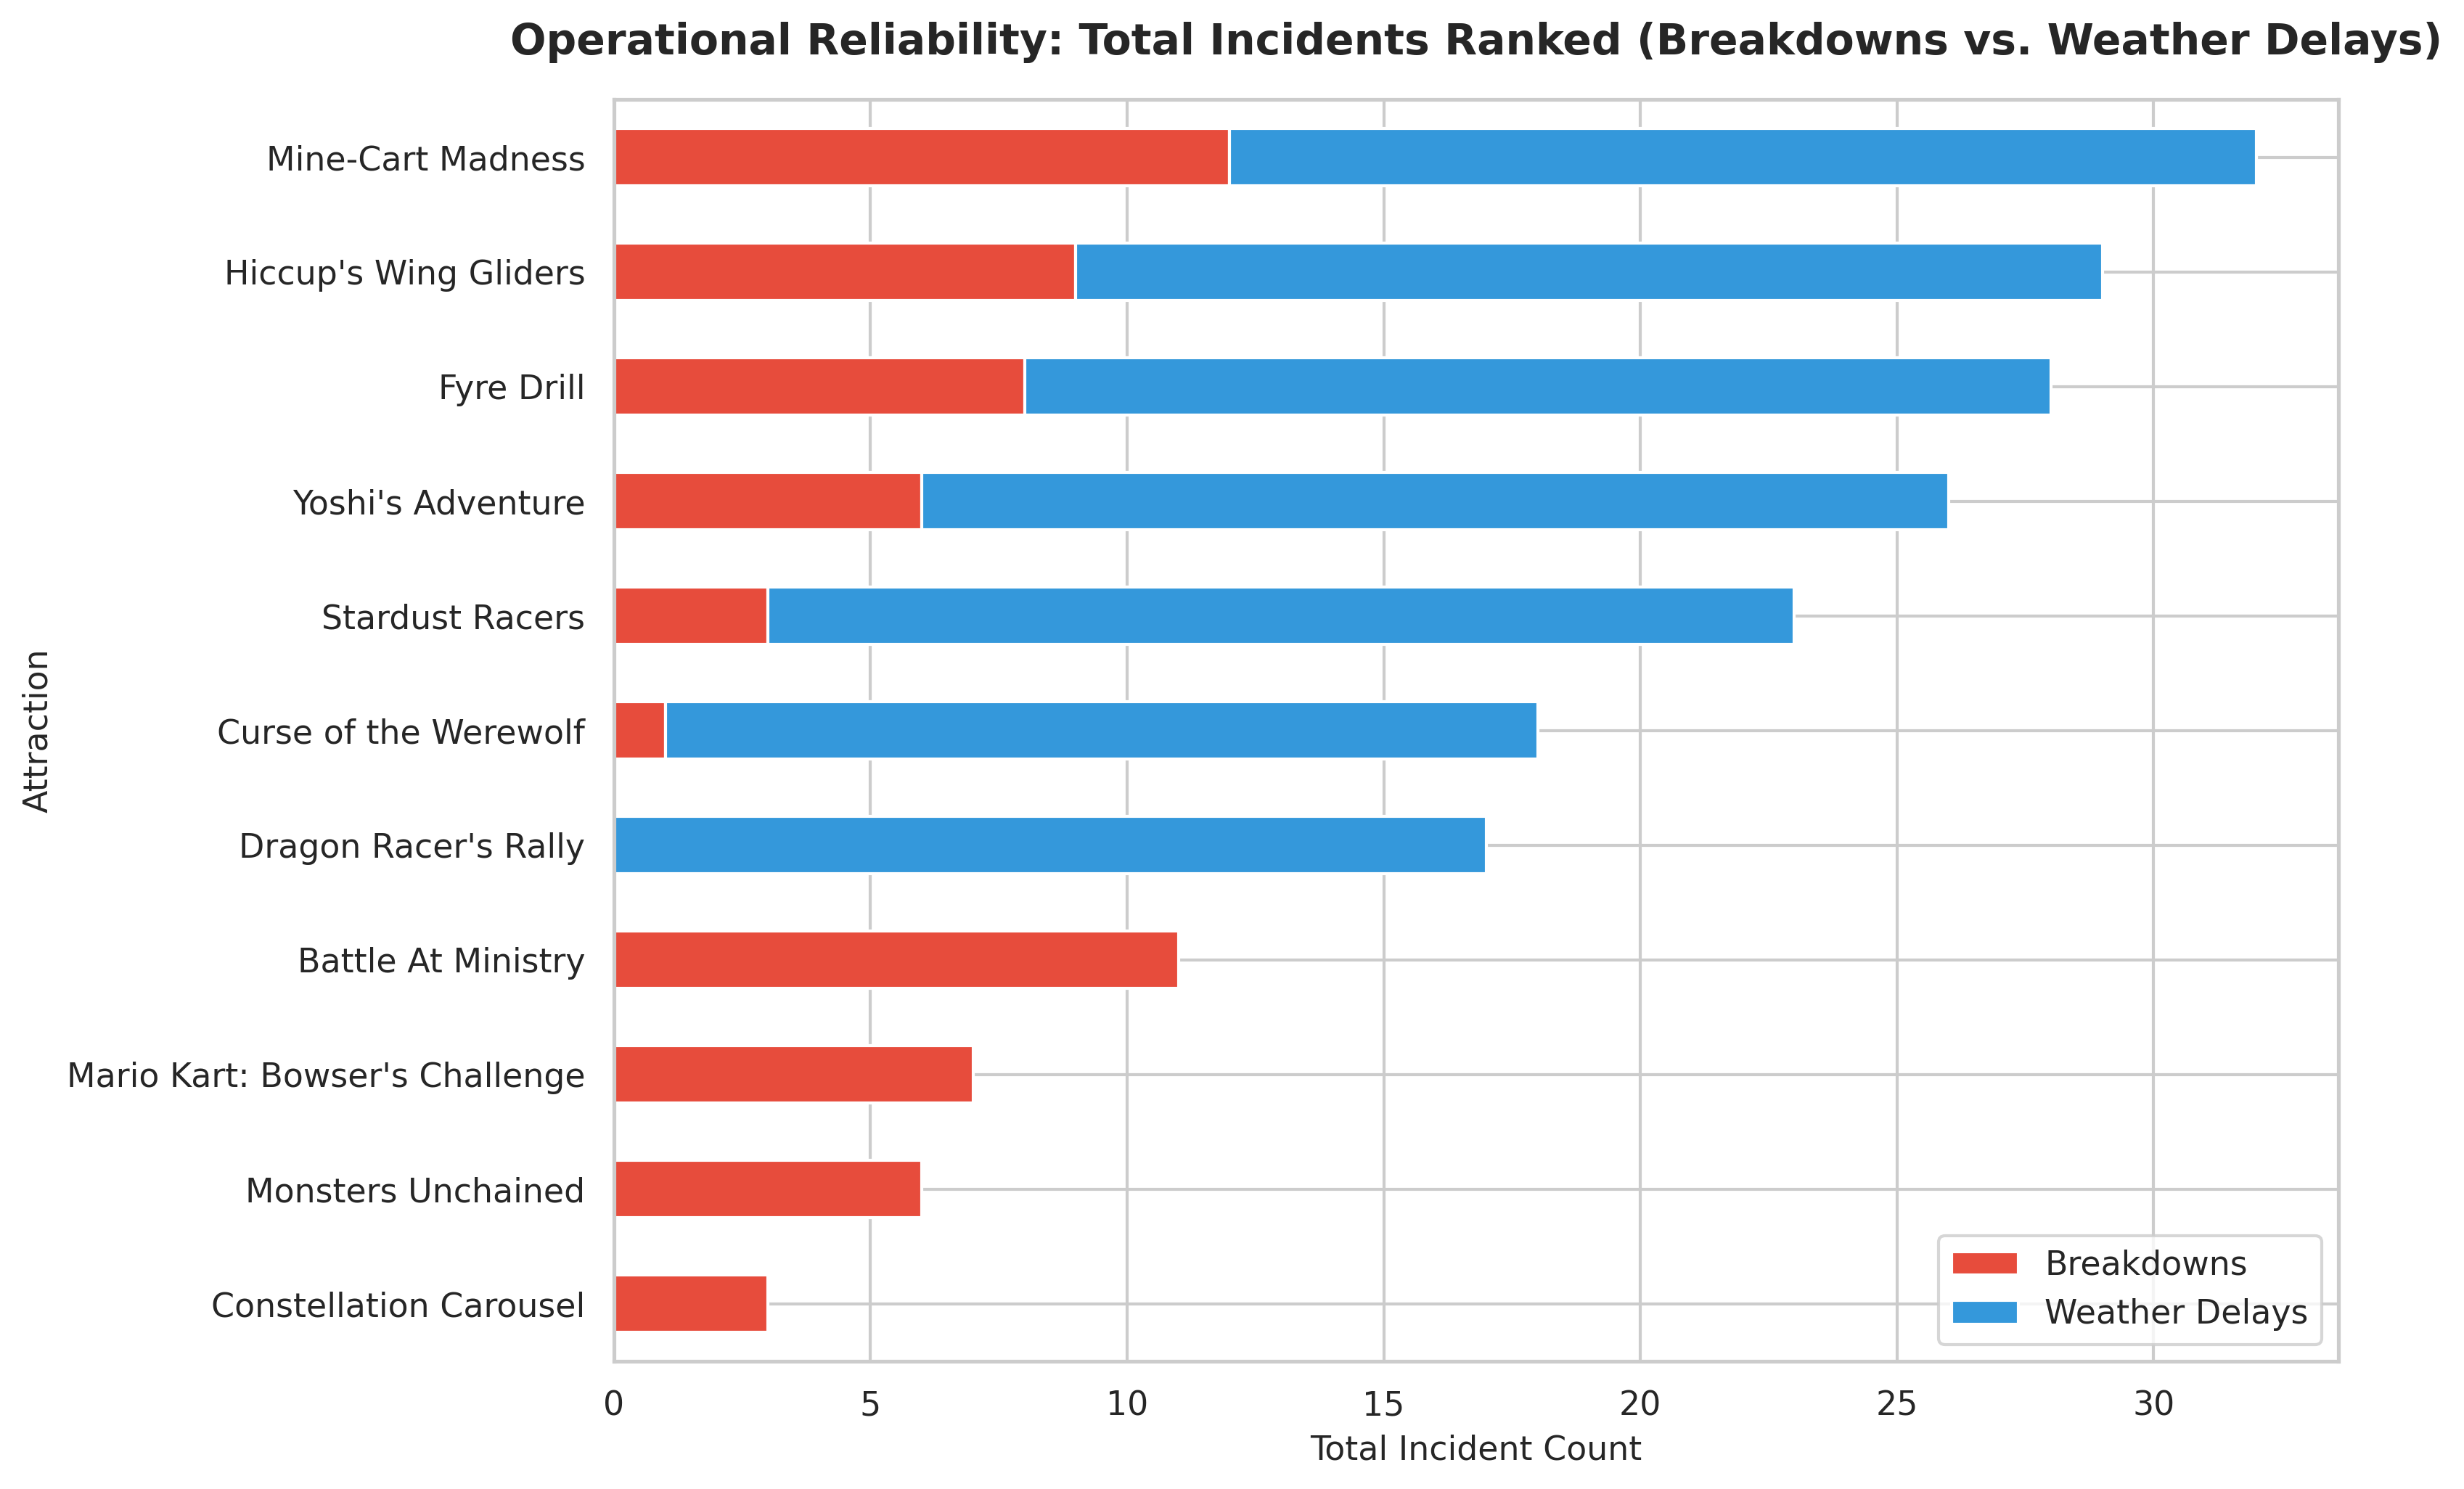

In [53]:
results_df = pd.read_excel(filepath, sheet_name="Results", header=None)

# Extract specific metric columns (Ride Name, Total Delays, Breakdowns) from the summary tab
reliability_df = results_df.iloc[1:13, [1, 17, 19]].copy()
reliability_df.columns = ["Ride Names", "Delays", "Breakdowns"]

reliability_df["Ride Names"] = reliability_df["Ride Names"].str.strip()
reliability_df["Delays"] = pd.to_numeric(reliability_df["Delays"], errors="coerce")
reliability_df["Breakdowns"] = pd.to_numeric(reliability_df["Breakdowns"], errors="coerce")
reliability_df = reliability_df.dropna(subset=["Ride Names"])

# Isolate weather-related closures from mechanical breakdowns
reliability_df["Weather Delays"] = reliability_df["Delays"] - reliability_df["Breakdowns"]

# Sort by total incident volume to surface the most problematic rides at the top of the bar chart
reliability_df = reliability_df.sort_values(by="Delays", ascending=True)

# Generate Stacked Bar Chart
fig, ax = plt.subplots(figsize=(11, 7))
reliability_df.set_index("Ride Names")[["Breakdowns", "Weather Delays"]].plot(
    kind="barh", stacked=True, ax=ax, color=["#e74c3c", "#3498db"]
)

plt.title(
    "Operational Reliability: Total Incidents Ranked (Breakdowns vs. Weather Delays)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Total Incident Count", fontsize=11)
plt.ylabel("Attraction", fontsize=11)
plt.legend(["Breakdowns", "Weather Delays"])
plt.tight_layout()
plt.savefig("ride_reliability_ranked.png")

As illustrated in the reliability breakdown, Epic Universe's outdoor attractions face significant operational vulnerability, with 7 of the 11 rides exposed to Florida's variable weather patterns. Mine-Cart Madness records the highest total downtime, driven by a combination of weather-related halts and mechanical breakdowns. Meanwhile, Battle At The Ministry demonstrates only a mechanical reliability concern, experiencing frequent breakdowns while being indoors and not suffering from weather interruptions.


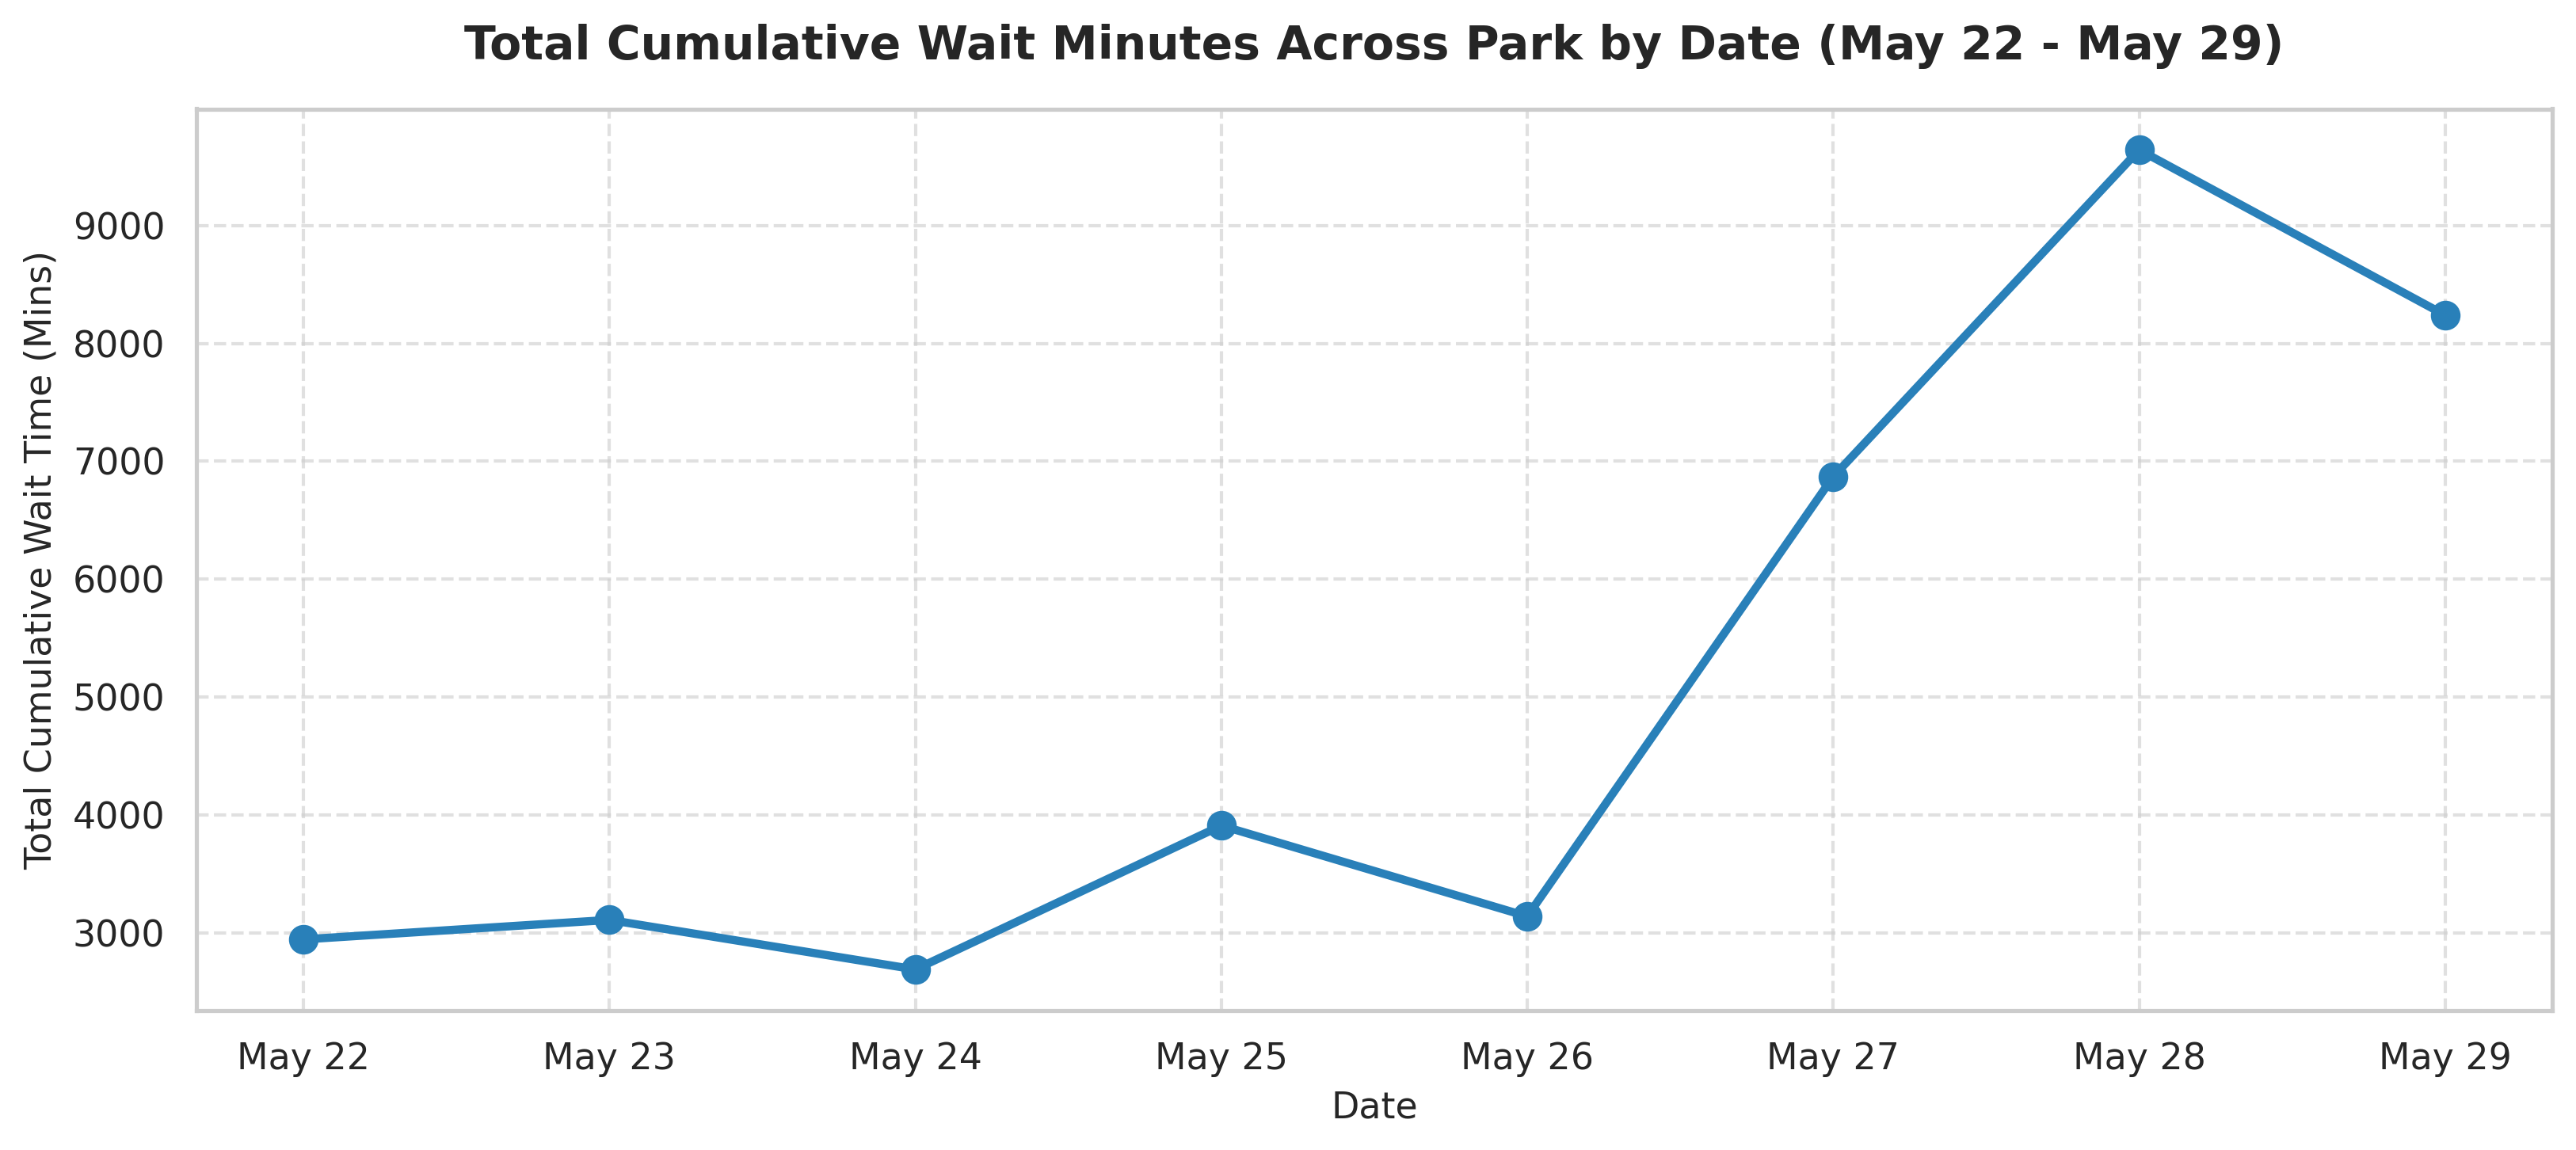

In [63]:
daily_totals = results_df.iloc[1:10, [21, 22]].copy()
daily_totals.columns = ["Date", "TotalWaitMinutes"]

# Standardize date format for proper chronological time-series plotting
daily_totals["Date"] = pd.to_datetime(
    daily_totals["Date"], format="%b %d", errors="coerce"
).dt.strftime("%b %d")
daily_totals["TotalWaitMinutes"] = pd.to_numeric(
    daily_totals["TotalWaitMinutes"], errors="coerce"
)
daily_totals = daily_totals.dropna()

# Generate Time-Series Line Plot
plt.figure(figsize=(11, 5))
plt.plot(
    daily_totals["Date"],
    daily_totals["TotalWaitMinutes"],
    marker="o",
    color="#2980b9",
    linewidth=2.5,
    markersize=8,
)
plt.title(
    "Total Cumulative Wait Minutes Across Park by Date (May 22 - May 29)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Total Cumulative Wait Time (Mins)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("daily_congestion_trend.png")

As demonstrated by the data, Universal rapidly expanded park capacity during this window, with total daily wait times jumping from under 4,000 cumulative minutes to roughly double on May 27th-29th. Consequently, to generate actionable and realistic wait-time insights, subsequent analysis must focus specifically on operating days that are more realistic capacity expectations.

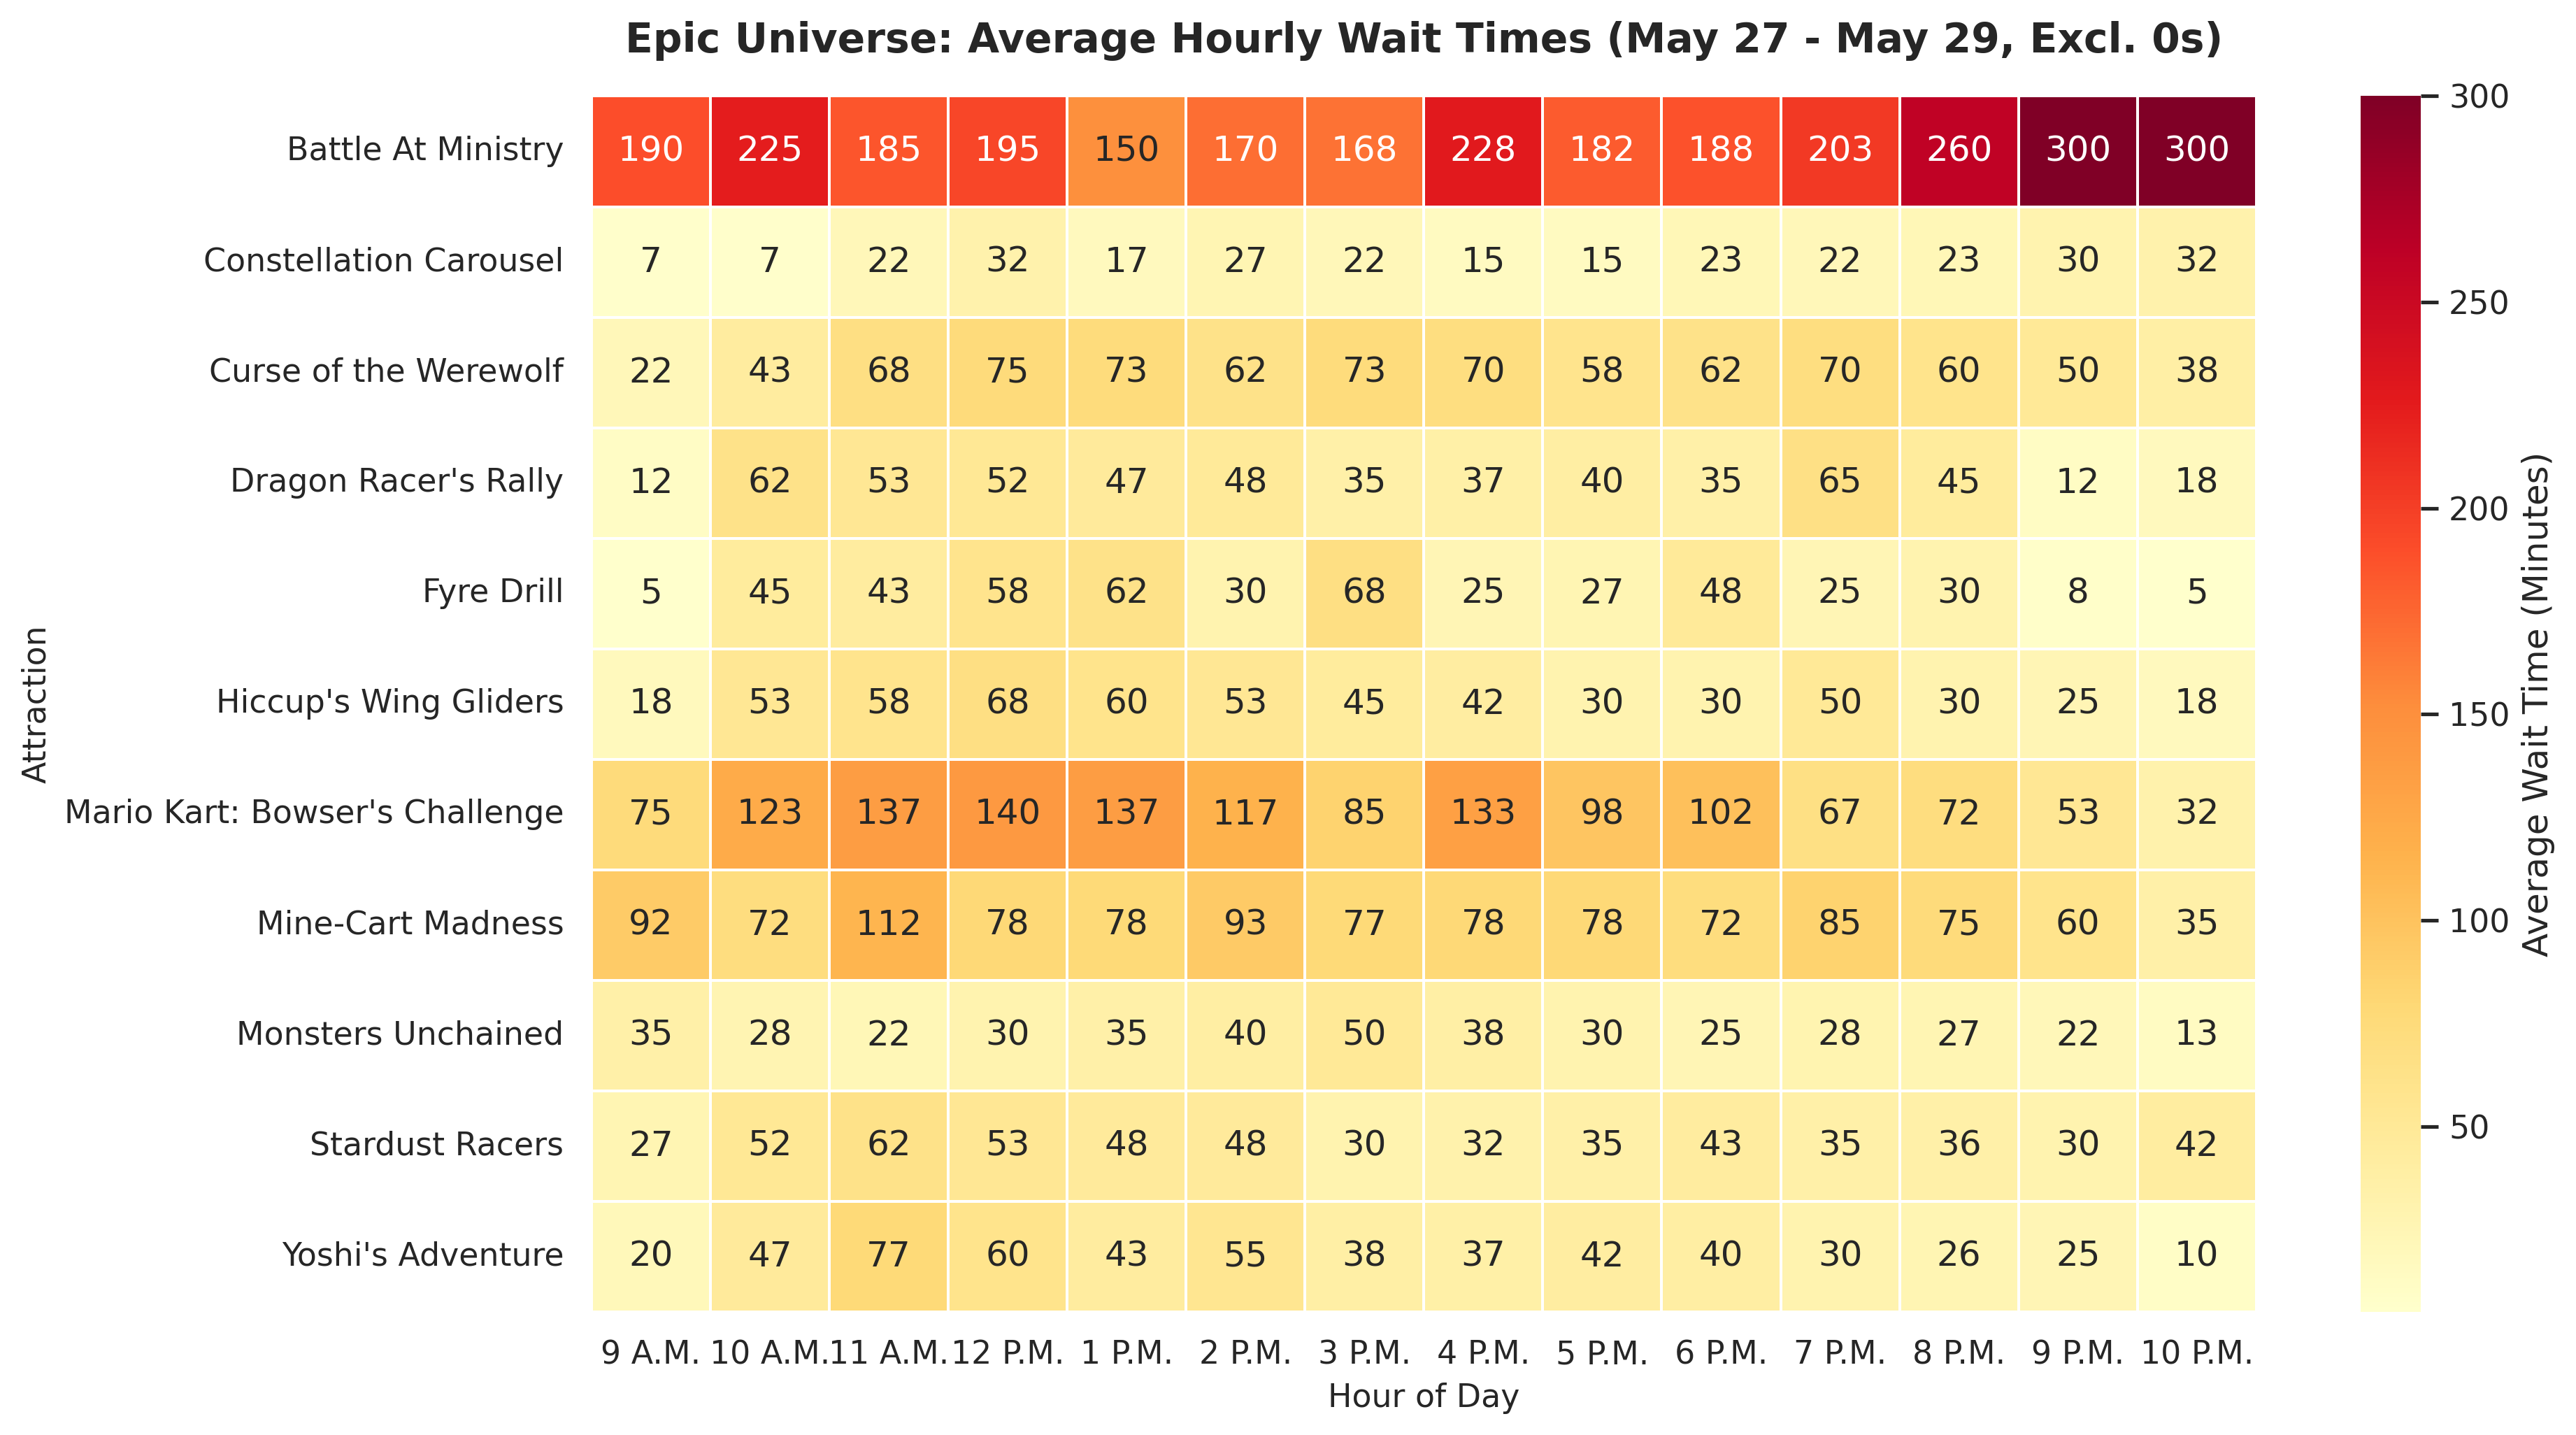

In [55]:
# Isolate data for the target window to analyze wait time behaviors on specific days
target_dates = ["2025-05-27", "2025-05-28", "2025-05-29"]
filtered_date_df = long_df[long_df["Date"].isin(target_dates)].copy()

# Exclude 0-minute wait times to prevent closed ride states from skewing the mean wait times downward
filtered_date_df["WaitTime"] = filtered_date_df["WaitTime"].replace(0, float("nan"))

pivot_wait_filtered = filtered_date_df.pivot_table(
    index="Ride Names", columns="Hour", values="WaitTime", aggfunc="mean"
)

# Enforce chronological sorting over Pandas' default alphabetical sort
existing_hours = [h for h in hour_order if h in pivot_wait_filtered.columns]
pivot_wait_filtered = pivot_wait_filtered[existing_hours]

# Generate Filtered Heatmap
plt.figure(figsize=(13, 7))
sns.heatmap(
    pivot_wait_filtered,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Average Wait Time (Minutes)"},
)
plt.title(
    "Epic Universe: Average Hourly Wait Times (May 27 - May 29, Excl. 0s)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Hour of Day", fontsize=11)
plt.ylabel("Attraction", fontsize=11)
plt.tight_layout()
plt.savefig("hourly_wait_heatmap_may27_29.png")

By isolating the May 27–28 capacity increase window, this heatmap provides a realistic preview of guest wait times under expanded park capacity. As expected, system-wide queue times escalate significantly—with Battle At The Ministry maxing out its queue at 8:00 PM. While Mario Kart, Mine-Cart Madness, and Battle At The Ministry retain their status as the park's top three crowd magnets, notable efficiency outliers emerge: despite high popularity, Monsters Unchained maintains remarkably low wait times, pointing to exceptional efficiency. Similarly, Stardust Racers effectively churns through crowds and keeps queues relatively short despite being an E-ticket attraction.

In [56]:
import random

# Isolate known high-capacity days (May 27-29) to model peak operational stress
surge_sheets = ["527", "528", "529"]
daily_data = []

for sheet in surge_sheets:
    raw_df = pd.read_excel(filepath, sheet_name=sheet, header=None)

    # Dynamically locate the '9 A.M.' anchor to account for shifting header rows
    h_idx = next((idx for idx, row in raw_df.iterrows() if "9 A.M." in row.values), None)

    if h_idx is not None:
        df = pd.read_excel(filepath, sheet_name=sheet, header=h_idx)
        cols = list(df.columns)
        df = df.rename(columns={cols[1]: "Ride Names"})

        # Filter out empty records and generalized park weather rows
        df = df.dropna(subset=["Ride Names"])
        df = df[df["Ride Names"].astype(str).str.strip() != "Weather"]
        daily_data.append(df)

master_surge = pd.concat(daily_data, ignore_index=True)

# Standardize time series data into a long format for aggregate modeling
hour_cols = [
    c for c in master_surge.columns
    if "A.M." in str(c) or "P.M." in str(c) or "AM" in str(c) or "PM" in str(c)
]
long_df = master_surge.melt(
    id_vars=["Ride Names"],
    value_vars=hour_cols,
    var_name="Hour",
    value_name="WaitTime",
)

long_df["Hour"] = long_df["Hour"].str.strip()
long_df["Ride Names"] = long_df["Ride Names"].str.strip()
long_df["WaitTime"] = pd.to_numeric(long_df["WaitTime"], errors="coerce").fillna(0)

# Construct the baseline wait time matrix for downstream simulation or routing
avg_wait_matrix = long_df.pivot_table(
    index="Ride Names", columns="Hour", values="WaitTime", aggfunc="mean"
)

# Enforce chronological sequence for time-based routing logic
hour_order = [
    "9 A.M.", "10 A.M.", "11 A.M.", "12 P.M.", "1 P.M.", "2 P.M.",
    "3 P.M.", "4 P.M.", "5 P.M.", "6 P.M.", "7 P.M.", "8 P.M.",
    "9 P.M.", "10 P.M.",
]
existing_hours = [h for h in hour_order if h in avg_wait_matrix.columns]
avg_wait_matrix = avg_wait_matrix[existing_hours]
rides = list(avg_wait_matrix.index)

In [62]:

# Define distinct operational windows for breaks, protecting the 9 A.M. slot for rope-drop strategy
snack_range = ["10 A.M.", "11 A.M."]
lunch_range = ["12 P.M.", "1. P.M.", "2 P.M.", "3 P.M."] if "1. P.M." in [c for c in avg_wait_matrix.columns] else ["12 P.M.", "1 P.M.", "2 P.M.", "3 P.M."]
dinner_range = ["4 P.M.", "5 P.M.", "6 P.M.", "7 P.M.", "8 P.M.", "9 P.M."]

all_rides = list(avg_wait_matrix.index)

# Automatically anchor the optimization strategy around high-demand anchor attractions like Ministry
ministry_ride = next(
    (r for r in all_rides if "Ministry" in str(r)), "Battle At Ministry"
)
other_rides = [r for r in all_rides if r != ministry_ride]

random.seed(42)
best_wait = float("inf")
best_schedule = []
best_break_combo = None

# Execute Monte Carlo simulation across break permutations and ride sequences
for _ in range(150000):
    snack_h = random.choice(snack_range)
    lunch_h = random.choice(lunch_range)
    dinner_h = random.choice(dinner_range)

    # Ensure all three break slots occupy mutually exclusive hours
    if len({snack_h, lunch_h, dinner_h}) < 3:
        continue

    break_slots = {
        snack_h: "Snack Break",
        lunch_h: "Lunch",
        dinner_h: "Dinner",
    }

    shuffled_rides = other_rides.copy()
    random.shuffle(shuffled_rides)

    current_wait = 0
    current_schedule = []
    other_ride_idx = 0

    for hour in existing_hours:
        if hour in break_slots:
            current_schedule.append(
                {
                    "Time": hour,
                    "Activity": break_slots[hour],
                    "WaitTime": 0,
                }
            )
        elif hour == "9 A.M.":
            # Exploit the morning low-wait window via tactical rope-drop routing
            w = avg_wait_matrix.loc[ministry_ride, hour]
            current_wait += w
            current_schedule.append(
                {
                    "Time": hour,
                    "Activity": f"{ministry_ride} (Rope Drop)",
                    "WaitTime": w,
                }
            )
        else:
            if other_ride_idx < len(shuffled_rides):
                r = shuffled_rides[other_ride_idx]
                w = avg_wait_matrix.loc[r, hour]
                current_wait += w
                current_schedule.append(
                    {
                        "Time": hour,
                        "Activity": f"{r}",
                        "WaitTime": w,
                    }
                )
                other_ride_idx += 1

    # Keep current state if it minimizes cumulative wait time
    if current_wait < best_wait:
        best_wait = current_wait
        best_schedule = current_schedule
        best_break_combo = (snack_h, lunch_h, dinner_h)

# Output optimization results
optimal_df = pd.DataFrame(best_schedule)
print(
    f"=== OPTIMAL BREAKS: Snack={best_break_combo[0]},"
    f" Lunch={best_break_combo[1]}, Dinner={best_break_combo[2]} ==="
)
print(f"Total Expected Wait Time: {best_wait:.1f} mins\n")
print(optimal_df[["Time", "Activity", "WaitTime"]].to_string(index=False))

=== OPTIMAL BREAKS: Snack=11 A.M., Lunch=1 P.M., Dinner=5 P.M. ===
Total Expected Wait Time: 351.7 mins

   Time                       Activity   WaitTime
 9 A.M. Battle At Ministry (Rope Drop) 126.666667
10 A.M.         Constellation Carousel   6.666667
11 A.M.                    Snack Break   0.000000
12 P.M.             Monsters Unchained  20.000000
 1 P.M.                          Lunch   0.000000
 2 P.M.                     Fyre Drill  20.000000
 3 P.M.              Yoshi's Adventure  38.333333
 4 P.M.           Dragon Racer's Rally  36.666667
 5 P.M.                         Dinner   0.000000
 6 P.M.          Hiccup's Wing Gliders  20.000000
 7 P.M.                Stardust Racers  11.666667
 8 P.M.          Curse of the Werewolf  20.000000
 9 P.M.              Mine-Cart Madness  20.000000
10 P.M. Mario Kart: Bowser's Challenge  31.666667


By utilizing a Monte Carlo simulation across peak operational windows, this model successfully generates a customized itinerary that minimizes cumulative wait times while maximizing attraction throughput.

**Future Iterations:**
* **Weather Integration:** Incorporating weather forecasts to dynamically adjust for rain-related ride closures and weather delays.
* **Smaller Time Slots:** Expanding scheduling resolution beyond strict hourly blocks to account for 15 or 30-minute intervals.